# Notebook 2 — Heterogeneous autonomous communication: without vs. with interoperability

**Project:** Real Autonomy in Autonomous Haulage · *Digital-twin experiments*
**Site (anonymised):** *Mine A*, open-pit copper mine, *Region R* · **Operator (anonymised):** *Company X*
**Runtime:** Google Colab (CPU is enough) · **Dependencies:** `numpy`, `pandas`, `matplotlib`, `scipy` (pre-installed in Colab)

> **Central question.** What happens to an autonomous haul fleet that shares the pit with manual vehicles, light vehicles, support equipment and other autonomy stacks when there is **no heterogeneous communication layer**, when there is **partial** coverage, and when there is **full** interoperability?

**Three scenarios**

| Scenario | `comms_cov` | Reading |
|---|---|---|
| **A – No heterogeneous comms** | 0.0 | Each autonomy stack sees the others only as obstacles (perception only) |
| **B – Partial** | 0.5 | Some agents/zones share intent (e.g. radio/V2X coverage gaps) |
| **C – Full interoperability** | 1.0 | Shared intent, right-of-way and shovel handshake for every agent |

**How to use this notebook.** Run the cells top to bottom (*Runtime → Run all*). Every experiment uses fixed random seeds, so you should reproduce the numbers quoted in the interpretation cells within the printed confidence intervals. Result cells are followed by an **input and output interpretation** section that states what the table or figure supports and what it does not.

**Anonymisation.** Company, mine, region and equipment identifiers were replaced (*Company X*, *Mine A*, *Region R*, shovels `SH-1…SH-5`, trucks `AHT-01…AHT-23`). The Time Usage Model codes, the ten cycle phases and the KPI definitions are kept exactly as in the source documents because they are the shared language of the analysis.


## 0. Contents
1. Mechanism inputs and assumptions
2. Shared simulator
3. Three-scenario output comparison
4. TUM time redistribution
5. Traffic-density × coverage sensitivity
6. Assumption robustness
7. Limitations
8. References
9. Disclaimer


## 1. Mechanisms and assumptions
Autonomous trucks meet *foreign agents* while travelling (manual vehicles, light vehicles, dozers, other-OEM autonomous trucks). Autonomy stacks are conservative: if they cannot know another agent's intent they stop [ISO]. In the model:

* An **interaction event** occurs at rate `lam_int` per travelling minute (nominal 0.02, i.e. about one every 50 min of driving).
* With probability `comms_cov` the encounter is **negotiated** through shared intent: a short slow-down (mean 0.4 min, TUM 4070).
* Otherwise it is a **hard stop** (mean 3.5 min, TUM 4070) and with probability `p_astop` = 6 % it escalates to an **emergency A-stop** (mean 14 min, TUM 4110) [TUM].
* Truck–shovel communication removes part of spotting and wait-for-load time: `handshake_gain = 0.5 × coverage` (up to 35 % of those two times).
* Dispatch is the same in all scenarios (greedy, 2-min information lag), so the only thing that changes is communication.

> **Assumption warning.** The event rate, stop durations, escalation probability and handshake gain are *engineering assumptions*, not measurements. Section 6 shows how conclusions move when they change. Replace them with FMS event exports (codes 4070, 4110, 5060) to turn this into a measured business case.

## 2. Simulator code (shared)

In [1]:
import numpy as np, pandas as pd, math
from scipy.stats import t as student_t
try:
    from IPython.display import display
except ImportError:          # plain-python fallback
    display = print
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
from collections import deque
from dataclasses import dataclass, replace

# ---------------------------------------------------------------- state ids
TE, QS, SS, WL, LD, TF, QK, SK, WD, DP, DN, RF, HD, E70, E110, E60, PD = range(17)
PHASES = ["Travelling Empty", "Queuing At Source", "Spotting At Source", "Wait for load", "Loading",
          "Travelling Full", "Queuing at sink", "Spotting at sink", "Wait for Dump", "Dumping"]
SLOT_NAME = PHASES + ["Breakdown (5000)", "Refuel (2020)", "Hold: wait dispatch/approval (4060/4150)",
                      "Obstacle / interaction stop (4070)", "Emergency A-stop (4110)", "Autonomy HW event (5060)", "Process delays (2xxx/4xxx)"]
SLOT_CODE = [1010, 7010, 1010, 7000, 1010, 1010, 7020, 1010, 7000, 1010, 5000, 2020, 4060, 4070, 4110, 5060, 4000]
QUEUE_SLOTS = (QS, QK)              # non value-adding queues (TUM 7010 / 7020)
DOWN_SLOTS = (DN, E60)              # equipment downtime (TUM 5xxx)
CYCLE_SLOTS = list(range(10))

# Reference values read from the (anonymised) operations dashboard, 8-16 Mar window
REF = {"Travelling Empty": 9.90, "Queuing At Source": 6.06, "Spotting At Source": 1.03, "Wait for load": 1.24,
       "Loading": 2.42, "Travelling Full": 9.14, "Queuing at sink": 1.56, "Spotting at sink": 0.70,
       "Wait for Dump": 0.37, "Dumping": 1.09}
REF_KPI = {"cycle_time": 33.51, "availability": 84.39, "utilization": 66.20, "tph_productive": 787.01,
           "hang_time": 2.24, "load_factor_t": 338.0}


@dataclass
class P:
    n_trucks: int = 23
    T: float = 720.0            # one 12 h shift, minutes
    warm: float = 60.0          # warm-up discarded from KPIs
    dt: float = 0.25
    payload: float = 338.0
    # per-shovel geometry (minutes) -> 5 active shovels (a 6th is out of service in the reference data)
    te: tuple = (7.0, 9.1, 10.2, 12.8, 14.4)
    tf: tuple = (6.6, 8.6, 9.6, 11.8, 13.4)
    load: tuple = (2.2, 2.4, 2.4, 2.6, 2.7)
    spot_src: float = 1.03
    wait_load: float = 1.24
    spot_sink: float = 0.70
    wait_dump: float = 0.37
    dump: float = 1.09
    sink_bays: int = 2
    sink_block_mtbf: float = 60.0   # crusher / dump-pocket blockages (min between events)
    sink_block_min: float = 7.0
    static_alloc: tuple = (9, 5, 4, 3, 2)
    cv: float = 0.25
    mtbf_h: float = 10.0
    mttr_h: float = 1.85
    shovel_mtbf_h: float = 30.0
    shovel_mttr_h: float = 1.5
    refuel_min: float = 12.0
    proc_p: float = 0.40        # prob. of a process delay (shift hand-over, lock-outs, weather...) at a decision point
    proc_mean: float = 8.0
    # interaction with heterogeneous traffic (manual / light vehicles / other autonomy stacks)
    lam_int: float = 0.020      # events per travelling minute
    comms_cov: float = 0.5      # 0 = no heterogeneous comms, 1 = full interoperability
    d_soft: float = 0.4
    d_hard: float = 3.5
    p_astop: float = 0.06       # probability that an uncoordinated hard stop escalates to an A-stop
    d_astop: float = 14.0
    lam_hw: float = 0.0015      # autonomy hardware events per travelling minute
    d_hw: float = 6.0
    handshake_gain: float = 0.0  # fraction of spot/wait-for-load time removed by full truck-shovel comms
    shovel_outages: tuple = ()  # ((shovel, start_min, end_min), ...)
    system_outages: tuple = ()  # ((start_min, end_min), ...) central FMS / network outage
    fallback_min: float = 10.0  # after this long in an outage, centralised policies fall back to the static plan
    seed: int = 0


HALF_DT = 0.125   # a timer that is decremented every dt overshoots by dt/2 on average -> compensate


def _ln(rng, mean, cv):
    s2 = math.log(1 + cv * cv)
    return max(0.02, rng.lognormal(math.log(mean) - s2 / 2, math.sqrt(s2)) - HALF_DT)


class Sim:
    def __init__(self, p: P, policy):
        self.p, self.policy = p, policy
        seed_seq = np.random.SeedSequence(p.seed)
        env_seed, policy_seed = seed_seq.spawn(2)
        self.rng = np.random.default_rng(env_seed)
        self.policy_rng = np.random.default_rng(policy_seed)
        N, M = p.n_trucks, len(p.te)
        self.N, self.M = N, M
        self.state = [TE] * N; self.left = [0.0] * N; self.tgt = [0] * N
        self.evt_left = [0.0] * N; self.evt_slot = [E70] * N
        self.hold_left = [0.0] * N; self.pending_tgt = [0] * N
        self.disp_t = [0.0] * N; self.disp_phi = [None] * N
        self.cycle_start = [0.0] * N
        self.fail_t = [self.rng.exponential(p.mtbf_h * 60) for _ in range(N)]
        self.refuel_t = [self.rng.uniform(200, 560) for _ in range(N)]
        self.acct = np.zeros((N, 17))
        self.shq = [[] for _ in range(M)]; self.occ = [-1] * M
        self.committed = [0] * M
        self.down = [False] * M
        self.sh_next_fail = [self.rng.exponential(p.shovel_mtbf_h * 60) for _ in range(M)]
        self.sh_up_at = [0.0] * M
        self.idle = np.zeros(M); self.loads = np.zeros(M); self.qtime = np.zeros(M)
        self.skq = []; self.sink_occ = 0
        self.sink_next_block = self.rng.exponential(p.sink_block_mtbf); self.sink_blocked_until = 0.0
        self.dump_times = []
        self.trips = 0; self.cycles = []; self.n_evt = {E70: 0, E110: 0, E60: 0}
        self.n_touch = 0; self.hist = []; self.dlog = deque()
        self.t = 0.0; self.k = 0
        self.home = []
        for a, n in enumerate(p.static_alloc):
            self.home += [a] * n
        self.home = (self.home + [0] * N)[:N]
        self.qdown_since = [None] * N
        self.tons_log = []
        for i in range(N):
            a = self._pick(i)
            self._depart(i, a, frac=self.rng.uniform(0.2, 1.0))

    # ------------------------------------------------------------ observation API used by policies
    def obs(self, lag):
        if lag <= 0 or not self.hist:
            return list(self.committed), list(self.down)
        idx = max(0, len(self.hist) - 1 - int(round(lag / self.p.dt)))
        return self.hist[idx]

    def recent(self, lag):
        c = [0] * self.M
        for (t, a) in self.dlog:
            if t > self.t - lag:
                c[a] += 1
        return c

    def in_outage(self):
        for (a, b) in self.p.system_outages:
            if a <= self.t < b:
                return a
        return None

    def phys_queue(self):
        return [len(q) + (1 if self.occ[a] >= 0 else 0) for a, q in enumerate(self.shq)]

    # ------------------------------------------------------------ helpers
    def _pick(self, i, redirect=False):
        a = self.policy.choose(self, i, redirect)
        self.disp_phi[i] = getattr(self.policy, "last_phi", None)
        return a

    def _depart(self, i, a, frac=1.0):
        p = self.p
        self.tgt[i] = a; self.committed[a] += 1; self.disp_t[i] = self.t
        self.dlog.append((self.t, a))
        while self.dlog and self.dlog[0][0] < self.t - 30:
            self.dlog.popleft()
        self.state[i] = TE
        self.left[i] = _ln(self.rng, p.te[a], p.cv) * frac

    def _next(self, i):
        """decision point after dumping / repair / refuel"""
        p = self.p
        if self.t >= self.fail_t[i]:
            self.state[i] = DN
            self.left[i] = _ln(self.rng, p.mttr_h * 60, 0.5)
            self.fail_t[i] = self.t + self.left[i] + self.rng.exponential(p.mtbf_h * 60)
            return
        if self.t >= self.refuel_t[i]:
            self.state[i] = RF; self.left[i] = _ln(self.rng, p.refuel_min, 0.2)
            self.refuel_t[i] = 1e9
            return
        if self.rng.random() < p.proc_p:
            self.state[i] = PD; self.left[i] = _ln(self.rng, p.proc_mean, 0.6)
            return
        self._dispatch(i)

    def _dispatch(self, i):
        p = self.p
        pol = self.policy
        if getattr(pol, "central", False):
            o = self.in_outage()
            if o is not None:
                if self.t - o < p.fallback_min:
                    self.state[i] = HD; self.left[i] = p.dt
                    self.pending_tgt[i] = -1
                    return
                a = self.home[i]
                self._depart(i, a); self.disp_phi[i] = None
                return
        a = self._pick(i)
        d = getattr(pol, "delay", lambda s, i: 0.0)(self, i)
        if d > 0:
            self.pending_tgt[i] = a; self.state[i] = HD; self.left[i] = d
            self.committed[a] += 1  # commitment visible immediately
            return
        self._depart(i, a)

    def _spawn_event(self, i):
        p, r = self.p, self.rng
        cov = p.comms_cov
        if r.random() < p.lam_int * p.dt:
            self.evt_slot[i] = E70
            if r.random() < cov:
                self.evt_left[i] = r.exponential(p.d_soft)
            else:
                self.evt_left[i] = r.exponential(p.d_hard)
                if r.random() < p.p_astop:
                    self.evt_slot[i] = E110
                    self.evt_left[i] = _ln(r, self.policy.astop_delay(self) if hasattr(self.policy, "astop_delay") else p.d_astop, 0.4)
                    self.n_evt[E110] += 1
                    self.n_touch += getattr(self.policy, "astop_touch", 1)
            self.n_evt[E70] += 1
        elif r.random() < p.lam_hw * p.dt:
            self.evt_slot[i] = E60; self.evt_left[i] = _ln(r, p.d_hw, 0.4); self.n_evt[E60] += 1

    # ------------------------------------------------------------ main loop
    def _truck(self, i):
        p, dt = self.p, self.p.dt
        if self.evt_left[i] > 0:
            self.acct[i][self.evt_slot[i]] += dt; self.evt_left[i] -= dt
            return
        st = self.state[i]
        self.acct[i][st] += dt
        if st in (TE, TF):
            self._spawn_event(i)
        if st == QS:
            a = self.tgt[i]
            if self.down[a]:
                if self.qdown_since[i] is None:
                    self.qdown_since[i] = self.t
                if self.t - self.qdown_since[i] >= self.policy.redirect_delay and not (
                        getattr(self.policy, "central", False) and self.in_outage() is not None):
                    self.shq[a].remove(i); self.committed[a] -= 1; self.qdown_since[i] = None
                    b = self._pick(i, redirect=True)
                    self._depart(i, b, frac=0.6)
            else:
                self.qdown_since[i] = None
            return
        if st == QK:
            return
        if st == HD:
            self.left[i] -= dt
            if self.pending_tgt[i] == -1:      # waiting out a system outage
                if self.in_outage() is None or self.t - self.in_outage() >= p.fallback_min:
                    self._dispatch(i)
                return
            if self.left[i] <= 0:
                a = self.pending_tgt[i]; self.committed[a] -= 1
                self._depart(i, a)
            return
        self.left[i] -= dt
        if self.left[i] > 0:
            return
        a = self.tgt[i]
        if st == TE:
            self.state[i] = QS; self.shq[a].append(i)
        elif st == SS:
            self.state[i] = WL; self.left[i] = _ln(self.rng, p.wait_load * (1 - 0.7 * p.handshake_gain), p.cv * 2)
        elif st == WL:
            self.state[i] = LD; self.left[i] = _ln(self.rng, p.load[a], p.cv)
        elif st == LD:
            self.state[i] = TF; self.left[i] = _ln(self.rng, p.tf[a], p.cv)
            self.occ[a] = -1; self.committed[a] -= 1; self.loads[a] += 1
            if hasattr(self.policy, "on_loaded"):
                self.policy.on_loaded(self, i, a, self.t - self.disp_t[i])
        elif st == TF:
            self.state[i] = QK; self.skq.append(i)
        elif st == SK:
            self.state[i] = WD; self.left[i] = _ln(self.rng, p.wait_dump, p.cv * 2)
        elif st == WD:
            self.state[i] = DP; self.left[i] = _ln(self.rng, p.dump, p.cv)
        elif st == DP:
            self.sink_occ -= 1
            if self.t >= p.warm:
                self.trips += 1; self.cycles.append(self.t - self.cycle_start[i]); self.dump_times.append(self.t)
            self.cycle_start[i] = self.t
            self._next(i)
        elif st in (DN, RF):
            self._next(i)
        elif st == PD:
            self._dispatch(i)

    def _shovels(self):
        p = self.p
        for a in range(self.M):
            # scripted + random outages (start only when shovel is free)
            forced = any(s == a and b <= self.t < c for (s, b, c) in p.shovel_outages)
            if self.down[a]:
                if not forced and self.t >= self.sh_up_at[a]:
                    self.down[a] = False
                    self.sh_next_fail[a] = self.t + self.rng.exponential(p.shovel_mtbf_h * 60)
            elif self.occ[a] == -1 and (forced or self.t >= self.sh_next_fail[a]):
                self.down[a] = True
                self.sh_up_at[a] = self.t + (0 if forced else _ln(self.rng, p.shovel_mttr_h * 60, 0.5))
            if not self.down[a] and self.occ[a] == -1 and self.shq[a]:
                i = self.shq[a].pop(0)
                self.occ[a] = i; self.state[i] = SS
                self.left[i] = _ln(self.rng, p.spot_src * (1 - 0.7 * p.handshake_gain), p.cv)
            if self.t >= p.warm:
                self.qtime[a] += p.dt * len(self.shq[a])
            if not self.down[a] and self.occ[a] == -1 and not self.shq[a] and self.t >= p.warm:
                self.idle[a] += p.dt

    def _sink(self):
        p = self.p
        if self.t >= self.sink_next_block:
            self.sink_blocked_until = self.t + _ln(self.rng, p.sink_block_min, 0.5)
            self.sink_next_block = self.sink_blocked_until + self.rng.exponential(p.sink_block_mtbf)
        if self.t < self.sink_blocked_until:
            return
        while self.sink_occ < p.sink_bays and self.skq:
            i = self.skq.pop(0); self.sink_occ += 1
            self.state[i] = SK; self.left[i] = _ln(self.rng, p.spot_sink, p.cv)

    def run(self):
        p = self.p
        for k in range(int(p.T / p.dt)):
            self.k = k; self.t = k * p.dt
            if abs(self.t - p.warm) < 1e-9:
                self.acct[:] = 0; self.idle[:] = 0; self.qtime[:] = 0; self.trips = 0; self.cycles = []; self.loads[:] = 0
                self.n_evt = {E70: 0, E110: 0, E60: 0}; self.n_touch = 0; self.dump_times = []
            for i in range(self.N):
                self._truck(i)
            self._shovels(); self._sink()
            self.hist.append((list(self.committed), list(self.down)))
            if len(self.hist) > 200:
                self.hist.pop(0)
        return self.metrics()

    def metrics(self):
        p = self.p
        tot = self.acct.sum()
        by = self.acct.sum(axis=0)
        down = sum(by[s] for s in DOWN_SLOTS)
        prod = sum(by[s] for s in CYCLE_SLOTS if s not in QUEUE_SLOTS)      # dashboard definition: cycle minus queues
        tum_prod = by[[TE, SS, LD, TF, SK, DP]].sum()                      # strict TUM 1010
        hrs = (p.T - p.warm) / 60
        tons = self.trips * p.payload
        trips = max(self.trips, 1)
        m = dict(trips=self.trips, tons=tons, tph_fleet=tons / hrs,
                 availability=100 * (1 - down / tot), utilization=100 * prod / (tot - down),
                 utilization_tum=100 * tum_prod / (tot - down),
                 tph_productive=tons / (prod / 60) if prod > 0 else 0.0,
                 cycle_time=float(by[CYCLE_SLOTS].sum() / trips),
                 cycle_wall=float(np.mean(self.cycles)) if self.cycles else float("nan"),
                 hang_time=float(self.idle.sum() / max(self.loads.sum(), 1)),
                 queue_src=by[QS] / trips, queue_sink=by[QK] / trips,
                 astops=self.n_evt[E110], stops=self.n_evt[E70], hw_events=self.n_evt[E60],
                 touches=self.n_touch, annual_Mt=tons / hrs * 8760 / 1e6,
                 loads=list(self.loads), idle=list(self.idle), qtime=list(self.qtime))
        for s in range(17):
            m["min_" + str(s)] = by[s] / trips           # minutes per trip in each slot
            m["share_" + str(s)] = 100 * by[s] / tot
        return m


# ================================================================ policies
class Static:
    name = "Static plan"; central = False; redirect_delay = 8.0
    def choose(self, s, i, redirect=False):
        return s.home[i] if not redirect else int(np.argmin([s.p.te[a] if not s.down[a] else 99 for a in range(s.M)]))


class Nearest:
    name = "Nearest shovel"; central = True; redirect_delay = 1.0
    def choose(self, s, i, redirect=False):
        return int(np.argmin([s.p.te[a] + (99 if s.down[a] else 0) for a in range(s.M)]))


class GreedyObs:
    """expected-time greedy on a (possibly stale) telemetry snapshot; svc = minutes of shovel time per truck"""
    central = True; redirect_delay = 1.0
    def __init__(self, lag=0.0, svc=4.5, noise=0.0, name=None):
        self.lag, self.svc, self.noise = lag, svc, noise
        self.name = name or f"Greedy (info lag {lag:g} min)"
    def choose(self, s, i, redirect=False):
        c, dn = s.obs(self.lag)
        est = []
        for a in range(s.M):
            e = max(s.p.te[a], c[a] * self.svc)
            if dn[a]:
                e += 60
            if self.noise:
                e *= s.policy_rng.lognormal(0, self.noise)
            est.append(e)
        return int(np.argmin(est))


# ================================================================ experiment helpers
def replicate(make_policy, n=20, seed0=0, keep_sims=False, **kw):
    """Run n independent replications (different random seeds) and return a DataFrame of KPIs."""
    rows, sims = [], []
    for k in range(n):
        sim = Sim(P(seed=seed0 + k, **kw), make_policy())
        m = sim.run(); m["seed"] = seed0 + k
        rows.append(m); sims.append(sim)
    df = pd.DataFrame(rows)
    return (df, sims) if keep_sims else df


def ci95(x):
    """Two-sided 95% half-width using Student's t for the finite replication count."""
    x = np.asarray(x, float)
    if len(x) < 2:
        return float("nan")
    return student_t.ppf(0.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x))


def tons_series(sim, bin_min=30):
    edges = np.arange(sim.p.warm, sim.p.T + 1e-9, bin_min)
    h, _ = np.histogram(sim.dump_times, bins=edges)
    return edges[:-1] + bin_min / 2, h * sim.p.payload / (bin_min / 60)     # t/h in each bin


def summarize(df, cols=("tph_fleet", "cycle_time", "queue_src", "queue_sink", "availability", "utilization", "tph_productive")):
    return pd.DataFrame({c: [f"{df[c].mean():.1f} ± {ci95(df[c]):.1f}"] for c in cols})


## 3. Three-scenario comparison
Thirty replications are run per scenario with the same seed indices. Communication changes the simulated trajectory, so a shared seed index does not imply an identical sequence of realised events.


B: partial (0.5)   vs A:   +548 t/h (+4.8 %), 95% CI ±179; better in 87% of shifts
C: full (1.0)      vs A:  +1016 t/h (+9.0 %), 95% CI ±213; better in 97% of shifts


,Scenario,Throughput t/h,±CI,Cycle min,Utilization %,Interaction stops,A-stops,Annualised Mt/yr
0,A: none (0.0),11333.2,167.9,29.4,71.1,132.6,7.8,99.3
1,B: partial (0.5),11881.2,149.5,28.6,72.7,140.7,4.8,104.1
2,C: full (1.0),12349.3,178.0,28.0,73.8,142.0,0.0,108.2


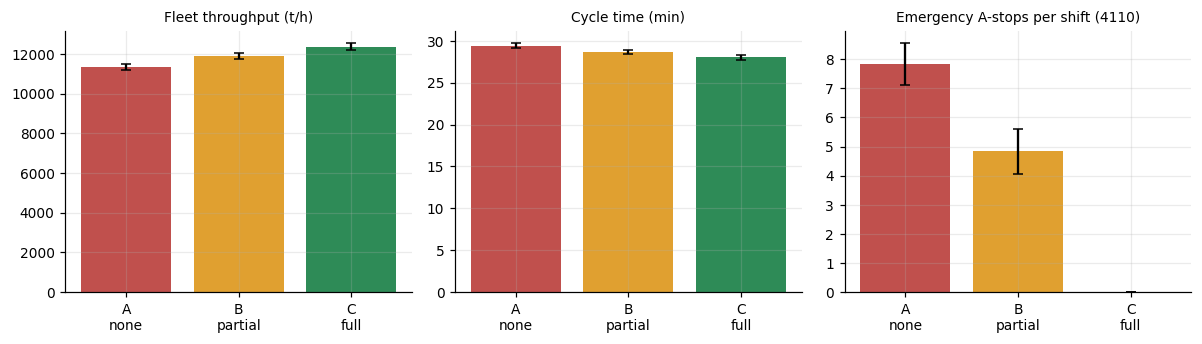

In [2]:
SC = {"A: none (0.0)": 0.0, "B: partial (0.5)": 0.5, "C: full (1.0)": 1.0}
res = {k: replicate(lambda: GreedyObs(2), n=30, comms_cov=c, handshake_gain=0.5 * c) for k, c in SC.items()}
rows = []
for k, d in res.items():
    rows.append({"Scenario": k, "Throughput t/h": d.tph_fleet.mean(), "±CI": ci95(d.tph_fleet), "Cycle min": d.cycle_time.mean(),
                 "Utilization %": d.utilization.mean(), "Interaction stops": d.stops.mean(), "A-stops": d.astops.mean(),
                 "Annualised Mt/yr": d.annual_Mt.mean()})
tab = pd.DataFrame(rows); display(tab.round(1))

A = res["A: none (0.0)"].tph_fleet.values
for k in list(SC)[1:]:
    d = res[k].tph_fleet.values - A
    print(f"{k:18s} vs A: {d.mean():+6.0f} t/h ({100*d.mean()/A.mean():+.1f} %), 95% CI ±{ci95(d):.0f}; better in {100*(d>0).mean():.0f}% of shifts")

fig, axs = plt.subplots(1, 3, figsize=(11, 3.2)); cols = ["#c0504d", "#e0a030", "#2e8b57"]
for ax, (m, t) in zip(axs, [("tph_fleet", "Fleet throughput (t/h)"), ("cycle_time", "Cycle time (min)"), ("astops", "Emergency A-stops per shift (4110)")]):
    ax.bar(range(3), [res[k][m].mean() for k in SC], yerr=[ci95(res[k][m]) for k in SC], color=cols, capsize=3)
    ax.set_xticks(range(3)); ax.set_xticklabels(["A\nnone", "B\npartial", "C\nfull"]); ax.set_title(t, fontsize=9)
plt.tight_layout(); plt.show()

### Input and output interpretation — three scenarios

* Mean throughput is **11,333 / 11,881 / 12,349 t/h** for no, partial and full interoperability. Partial minus none is **+548 ± 179 t/h** (+4.8 %); full minus none is **+1,016 ± 213 t/h** (+9.0 %). Both direct Student-*t* intervals are above zero in this simulation.
* Cycle time falls from **29.4 to 28.0 min** and dashboard-definition utilization rises from **71.1 % to 73.8 %** between no and full communication.
* Emergency A-stops fall from **7.8 to 4.8 to 0 per shift**. The zero under full coverage is a direct consequence of the model: escalation can occur only after an uncoordinated encounter, and full coverage eliminates that branch. It is not an empirical safety prediction.
* Interaction-stop counts rise from 132.6 to 142.0 because higher-throughput trucks spend more time travelling. The modeled benefit comes from shorter negotiated stops, elimination of escalation, and the shovel-handshake assumption—not from eliminating encounters.
* Annualised output (99.3 to 108.2 Mt/year) is a TUM-style scaling of simulated 11-h measurement windows, not a mine-plan forecast.

**Output conclusion.** Under the nominal assumptions, partial and full interoperability improve productivity, with full coverage producing the larger effect. Section 6 separates the road-interaction and shovel-handshake contributions.


## 4. Where the lost time goes (TUM codes)

Queue detail (aggregate queue share alone hides redistribution):


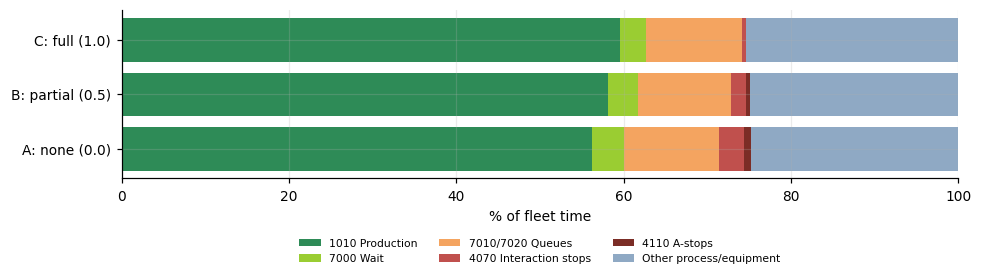

Scenario,A: none (0.0),B: partial (0.5),C: full (1.0)
Bucket,,,
1010 Production,56.16,58.12,59.57
4070 Interaction stops,2.99,1.75,0.49
4110 A-stops,0.74,0.44,0.00
7000 Wait,3.92,3.58,3.10
7010/7020 Queues,11.38,11.18,11.48
Other process/equipment,24.81,24.94,25.36


,A: none (0.0),B: partial (0.5),C: full (1.0)
Annualised production time (h/yr per truck),4920.0,5091.0,5219.0


,Scenario,"Queue at source (min/trip, 7010)","Queue at sink (min/trip, 7020)"
0,A: none (0.0),3.32,1.36
1,B: partial (0.5),2.96,1.43
2,C: full (1.0),2.70,1.65


In [3]:
parts = [("1010 Production", [TE, SS, LD, TF, SK, DP], "#2e8b57"), ("7000 Wait", [WL, WD], "#9acd32"), ("7010/7020 Queues", [QS, QK], "#f4a460"),
         ("4070 Interaction stops", [E70], "#c0504d"), ("4110 A-stops", [E110], "#7b2d26"), ("Other process/equipment", [PD, RF, HD, E60, DN], "#8fa9c4")]
fig, ax = plt.subplots(figsize=(9, 2.8)); rows = []
for i, (k, d) in enumerate(res.items()):
    left = 0
    for name, sl, col in parts:
        v = sum(d[f"share_{s}"].mean() for s in sl)
        ax.barh(i, v, left=left, color=col, label=name if i == 0 else None); left += v
        rows.append((k, name, v))
ax.set_yticks(range(3)); ax.set_yticklabels(list(SC)); ax.set_xlim(0, 100); ax.set_xlabel("% of fleet time"); ax.legend(ncol=3, fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.3), frameon=False)
plt.tight_layout(); plt.show()
piv = pd.DataFrame(rows, columns=["Scenario", "Bucket", "%"]).pivot(index="Bucket", columns="Scenario", values="%"); display(piv.round(2))
ann = pd.DataFrame({k: [sum(res[k][f"share_{s}"].mean() for s in [TE, SS, LD, TF, SK, DP]) / 100 * 8760] for k in SC}, index=["Annualised production time (h/yr per truck)"])
display(ann.round(0))
# Queue detail: the aggregate can remain stable while the bottleneck moves.
queue_detail = pd.DataFrame({
    "Scenario": list(SC),
    "Queue at source (min/trip, 7010)": [res[k].queue_src.mean() for k in SC],
    "Queue at sink (min/trip, 7020)": [res[k].queue_sink.mean() for k in SC],
})
print("Queue detail (aggregate queue share alone hides redistribution):")
display(queue_detail.round(2))


### Input and output interpretation — TUM redistribution

* Interaction stops (TUM 4070) fall from **2.99 % to 0.49 %** of fleet time and A-stops (4110) from **0.74 % to 0 %**. The A-stop result is structural to the scenario definition.
* Code 1010 production rises from **56.16 % to 59.57 %**, equivalent to **4,920 to 5,219 annualised production hours per truck** (+299 h/year under the × 8,760 convention).
* The combined 7010/7020 queue share remains close to **11.2–11.5 %**, but the bottleneck moves: source queue falls from **3.32 to 2.70 min/trip**, while sink queue rises from **1.36 to 1.65 min/trip**. The aggregate must not be read as “queues do not change.”
* Code 7000 wait time falls from **3.92 % to 3.10 %** because the scenario explicitly assumes that truck–shovel handshaking removes part of spotting and wait-for-load time.

**Output conclusion.** The productivity increase is accompanied by a redistribution of time among production, road stops, waits and queues. Aggregate queue share alone is insufficient to diagnose the mechanism.


## 5. Sensitivity: traffic density × communication coverage
A heat-map of throughput (8 replications per cell).

Gain full-vs-none by density: {0.005: np.float64(4.3), 0.01: np.float64(8.6), 0.02: np.float64(9.5), 0.03: np.float64(9.9), 0.04: np.float64(14.1), 0.05: np.float64(13.4)}


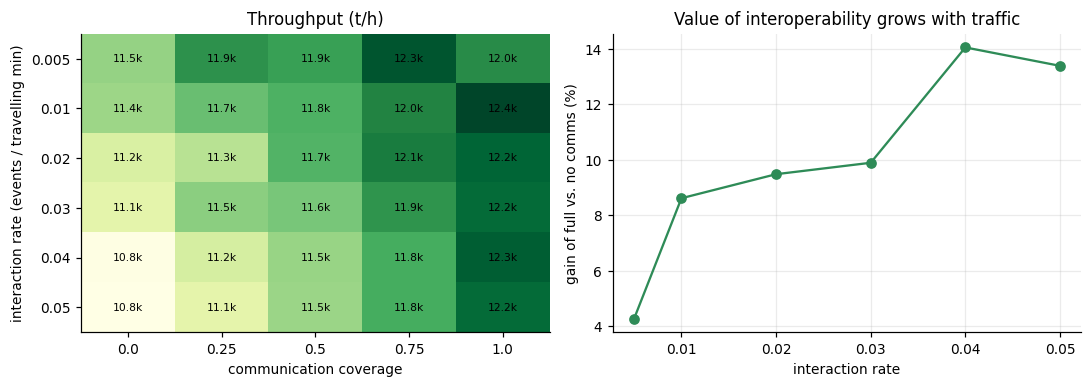

In [4]:
dens = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05]; covs = [0.0, 0.25, 0.5, 0.75, 1.0]
Z = np.zeros((len(dens), len(covs)))
for i, lam in enumerate(dens):
    for j, c in enumerate(covs):
        Z[i, j] = replicate(lambda: GreedyObs(2), n=8, lam_int=lam, comms_cov=c, handshake_gain=0.5 * c).tph_fleet.mean()
fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
im = axs[0].imshow(Z, cmap="YlGn", aspect="auto"); axs[0].grid(False)
for i in range(len(dens)):
    for j in range(len(covs)): axs[0].text(j, i, f"{Z[i,j]/1000:.1f}k", ha="center", va="center", fontsize=7)
axs[0].set_xticks(range(len(covs))); axs[0].set_xticklabels(covs); axs[0].set_yticks(range(len(dens))); axs[0].set_yticklabels(dens)
axs[0].set_xlabel("communication coverage"); axs[0].set_ylabel("interaction rate (events / travelling min)"); axs[0].set_title("Throughput (t/h)")
gain = 100 * (Z[:, -1] / Z[:, 0] - 1)
axs[1].plot(dens, gain, marker="o", color="#2e8b57"); axs[1].set_xlabel("interaction rate"); axs[1].set_ylabel("gain of full vs. no comms (%)"); axs[1].set_title("Value of interoperability grows with traffic")
plt.tight_layout(); plt.show()
print("Gain full-vs-none by density:", dict(zip(dens, np.round(gain, 1))))

### Input and output interpretation — density × coverage

The heat map uses eight shifts per cell; Student-*t* intervals for such small samples are wider than normal-approximation intervals.

* The full-versus-none gain is **4.3 %, 8.6 %, 9.5 %, 9.9 %, 14.1 % and 13.4 %** as the interaction rate increases from 0.005 to 0.05 events per travelling minute.
* Full coverage makes throughput **much less sensitive** to traffic density; it does not make it perfectly flat. Individual eight-shift cells remain noisy, and the small non-monotonic changes should not be interpreted as thresholds.
* The business-case implication is conditional: interoperability is more valuable in the simulated dense mixed-traffic settings because more uncoordinated stops are available to avoid.


## 6. Robustness to the assumptions
How large is the benefit of full interoperability if hard stops are shorter/longer and if escalation to A-stop is rarer/commoner? (8 replications per cell, nominal density.)

In [5]:
dh = [2.0, 3.5, 6.0]; pa = [0.03, 0.06, 0.12]
G = np.zeros((3, 3))
for i, d_h in enumerate(dh):
    for j, p_a in enumerate(pa):
        a = replicate(lambda: GreedyObs(2), n=8, d_hard=d_h, p_astop=p_a, comms_cov=0.0).tph_fleet.mean()
        c = replicate(lambda: GreedyObs(2), n=8, d_hard=d_h, p_astop=p_a, comms_cov=1.0, handshake_gain=0.5).tph_fleet.mean()
        G[i, j] = 100 * (c / a - 1)
display(pd.DataFrame(G, index=[f"hard stop {x} min" for x in dh], columns=[f"P(A-stop) {x}" for x in pa]).round(1))

# and with the handshake effect switched off (communication only helps on the road):
# same 30 seed indices as Section 3, so the three numbers below are directly comparable
road_only = replicate(lambda: GreedyObs(2), n=30, comms_cov=1.0, handshake_gain=0.0)
A_ = res["A: none (0.0)"].tph_fleet.values
d_full = res["C: full (1.0)"].tph_fleet.values - A_
d_road = road_only.tph_fleet.values - A_
print(f"Full interoperability vs none:            {d_full.mean():+6.0f} t/h ({100*d_full.mean()/A_.mean():+.1f} %, 95% CI ±{ci95(d_full):.0f})")
print(f"Road interactions only (no shovel handshake): {d_road.mean():+6.0f} t/h ({100*d_road.mean()/A_.mean():+.1f} %, 95% CI ±{ci95(d_road):.0f})")
print(f"Share of the full benefit that rests on the assumed shovel handshake: {100*(1 - d_road.mean()/d_full.mean()):.0f} %")


Full interoperability vs none:             +1016 t/h (+9.0 %, 95% CI ±213)
Road interactions only (no shovel handshake):   +372 t/h (+3.3 %, 95% CI ±178)
Share of the full benefit that rests on the assumed shovel handshake: 63 %


,P(A-stop) 0.03,P(A-stop) 0.06,P(A-stop) 0.12
hard stop 2.0 min,5.8,6.2,8.2
hard stop 3.5 min,7.4,9.5,10.7
hard stop 6.0 min,9.9,12.2,10.7


### Input and output interpretation — robustness

* Across hard-stop means of 2–6 min and A-stop probabilities of 3–12 %, full-versus-none gains range from **5.8 % to 12.2 %**. Longer hard stops generally increase the value of communication; A-stop probability also changes some cells, so the result is not independent of that assumption.
* With the shovel-handshake effect disabled, full road communication still adds **+372 ± 178 t/h** (**+3.3 %**) relative to no communication. Its direct 95 % interval remains above zero in this model.
* The full package adds **+1,016 ± 213 t/h** (+9.0 %). The calculation `1 − road-only/full` assigns **63 %** of that mean benefit to the handshake component.
* That 63 % is a **conditional one-at-a-time decomposition**, not a pure causal share: road coordination and shovel handshaking interact through cycle frequency and congestion. The shovel component is nevertheless the dominant unmeasured assumption and should be estimated from matched shovel data.

**Output conclusion.** The road-only effect is positive but materially smaller than the full modeled package. The headline result depends strongly on the assumed truck–shovel handshake.


## Limitations

* Interaction frequency, stop duration, escalation probability and handshake gain are engineering assumptions. FMS event logs and matched shovel observations are required to estimate them.
* “Communication” is represented by probabilities and durations, not message protocols, latency, cybersecurity, spatial dead zones or interoperability standards.
* Full coverage forces modeled A-stops from uncoordinated encounters to zero by construction. The notebook evaluates productivity, not collision risk or safety compliance [ISO].
* The 63 % handshake share is a conditional decomposition with interactions; it is not an invariant causal attribution.
* Student-*t* intervals are used, especially important for the eight-replication sensitivity cells. Statistical claims use direct seed-indexed differences.
* Environment and policy RNGs are separate, but scenario-dependent branches and routes still produce different later event histories. Equal seed indices are not identical shifts.
* The reduced-form mine omits grade/blend, route topology, weather and production-plan constraints. Its five-shovel calibration structure also overstates baseline hang time relative to the dashboard.
* Annualised tonnes and production hours are scaling conventions, not forecasts. External operational use requires held-out event-level validation.


## References

1. **[TUM]** Operator's *Operations & Supply Chain Management – Time Usage Model (TUM): Our Requirements*, v7.0 (12 Jan 2023), internal standard (Company X). Time definitions, classification categories, parameters (availability, utilization, annualised production time), reliability parameters (MTBF, MTTR) and the standard time codes.
2. **[DASH]** Autonomous-haulage operations dashboard pack ("Autonomous-Haulage Dashboard"), Mine A, extracts for 9–16 March 2025: Tonnage Origin/Destination, Crusher Feed, Availability, Utilization, Throughput, Autonomous Fleet (cycle phases), Shovel, Duration, Annualised, and the dashboard-by-dashboard KPI list.
3. **[GLOS]** *Full TUM Glossary* – general time terms, downtime classification, standard parameters, reliability parameters and code families.
4. **[KPI]** *KPI Control Template – Mine A (improved version)* – expected ranges: availability > 85 %, utilization > 60 %, MTBF > 10 h, MTTR < 2 h, hang time < 2 min, load factor 2.5–3 passes, non-productive time (7000–7020) < 10 %.
5. **[CYCLE]** Mining haul-cycle diagram: ten cycle phases – travelling empty, queuing/spotting at source, wait for load, loading, travelling full, queuing/spotting at sink, wait for dump, dumping.
6. **[BANKS]** Banks, J., Carson, J. S., Nelson, B. L. & Nicol, D. M. (2010). *Discrete-Event System Simulation* (5th ed.). Pearson. (Warm-up, replications, confidence intervals, verification and validation.)
7. **[LAW]** Law, A. M. (2015). *Simulation Modeling and Analysis* (5th ed.). McGraw-Hill.
8. **[LITTLE]** Little, J. D. C. (1961). A proof for the queuing formula L = λW. *Operations Research*, 9(3), 383–387.
9. **[AG]** Alarie, S. & Gamache, M. (2002). Overview of solution strategies used in truck dispatching systems for open pit mines. *International Journal of Surface Mining, Reclamation and Environment*, 16(1), 59–76.
10. **[ISO]** ISO 17757:2019. *Earth-moving machinery and mining – Autonomous and semi-autonomous machine system safety*.


## Disclaimer

This notebook is an exploratory simulation based on anonymised aggregate indicators and a simplified representation of an open-pit haulage system. It is not an operator model, a production forecast, a safety case or an operating recommendation. Parameters that were not observable—including event rates, communication effects and human-response times—are explicit assumptions, and the outputs are conditional on those assumptions and on the model structure.

Company, mine, location and equipment identifiers have been anonymised. The work is independent and is not endorsed by, or affiliated with, any mining company or technology vendor. Operational, investment and safety decisions require validation against held-out FMS event data, mine-plan constraints and the applicable engineering and safety standards.
